In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import math
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [26]:
train = pd.read_csv('../Models/data/training_data.csv')
test = pd.read_csv('../Models/data/test_data.csv')

In [27]:
train.head(5)

,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL),RESERVOIR_CLASSIFICATION
0,2012-01-01,Well_#2,9.5,3719,203.818,0.0,42.68000,1547.85,70.407,94,66,66,65,KEMA
1,2012-01-02,Well_#2,24.0,3640,207.344,0.0,44.57355,1451.32,114.117,885,533,533,365,KEMA
2,2012-01-03,Well_#2,24.0,3489,208.116,0.0,46.36498,1388.67,141.521,1802,1118,1118,710,KEMA
3,2012-01-04,Well_#2,24.0,3380,208.142,0.0,46.27880,1249.51,135.385,2590,1572,1572,1111,KEMA
4,2012-01-05,Well_#2,24.0,3303,208.188,0.0,46.43129,1168.99,133.258,3381,2026,2026,1517,KEMA


In [28]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5061 entries, 0 to 5060
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   PROD_DATE                             5061 non-null   object 
 1   WELL_NAME                             5061 non-null   object 
 2   ON_STREAM_HRS                         5061 non-null   float64
 3   BOTTOMHOLE_FLOWING_PRESSURE (PSI)     5061 non-null   int64  
 4   DOWNHOLE_TEMPERATURE (deg F)          5061 non-null   float64
 5   ANNULUS_PRESS (PSI)                   5061 non-null   float64
 6   CHOKE_SIZE (%)                        5061 non-null   float64
 7   WELL_HEAD_PRESSURE (PSI)              5061 non-null   float64
 8   WELL_HEAD_TEMPERATURE (deg F)         5061 non-null   float64
 9   CUMULATIVE_OIL_PROD (STB)             5061 non-null   int64  
 10  CUMULATIVE_FORMATION_GAS_PROD (MSCF)  5061 non-null   int64  
 11  CUMULATIVE_TOTAL_

In [29]:
train.nunique()

PROD_DATE                               2003
WELL_NAME                                 13
ON_STREAM_HRS                            305
BOTTOMHOLE_FLOWING_PRESSURE (PSI)       1710
DOWNHOLE_TEMPERATURE (deg F)            3608
ANNULUS_PRESS (PSI)                     3448
CHOKE_SIZE (%)                          3194
WELL_HEAD_PRESSURE (PSI)                4476
WELL_HEAD_TEMPERATURE (deg F)           4320
CUMULATIVE_OIL_PROD (STB)               4336
CUMULATIVE_FORMATION_GAS_PROD (MSCF)    4342
CUMULATIVE_TOTAL_GAS_PROD (MSCF)        4339
CUMULATIVE_WATER_PROD (BBL)             4202
RESERVOIR_CLASSIFICATION                   5
dtype: int64

In [30]:
# Check what reservoir labels are present in training data
print("Reservoirs in Training Set:")
print(train['RESERVOIR_CLASSIFICATION'].value_counts())

Reservoirs in Training Set:
RESERVOIR_CLASSIFICATION
KEMA    1957
DEPU    1555
ACHI     684
MAKO     438
JANI     427
Name: count, dtype: int64


In [31]:
le = LabelEncoder()
train['RESERVOIR_LABEL'] = le.fit_transform(train['RESERVOIR_CLASSIFICATION'])

# Save label map for decoding later
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Label Encoding Map:", label_map)

Label Encoding Map: {'ACHI': np.int64(0), 'DEPU': np.int64(1), 'JANI': np.int64(2), 'KEMA': np.int64(3), 'MAKO': np.int64(4)}


In [32]:
train.sample(5)

,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL),RESERVOIR_CLASSIFICATION,RESERVOIR_LABEL
1635,2013-04-17,Well_#6,24.0,2793,203.471,14.876,80.99091,52.528,109.643,0,0,0,0,KEMA,3
4661,2015-07-05,Well_#17,24.0,1747,158.538,640.488,80.90738,76.490,80.091,240297,223779,323236,279389,DEPU,1
2312,2013-02-27,Well_#7,24.0,3459,202.620,1137.330,65.74616,256.256,97.471,541728,405428,608172,1199069,KEMA,3
5059,2011-12-24,Well_#18,24.0,2357,159.730,0.000,59.23162,119.680,93.510,205399,181655,181655,179390,ACHI,0
2477,2011-10-06,Well_#8,24.0,2473,148.533,1188.070,70.06884,64.946,98.177,81506,84506,134989,63855,ACHI,0


<Axes: title={'center': 'Class Distribution'}, xlabel='RESERVOIR_CLASSIFICATION'>

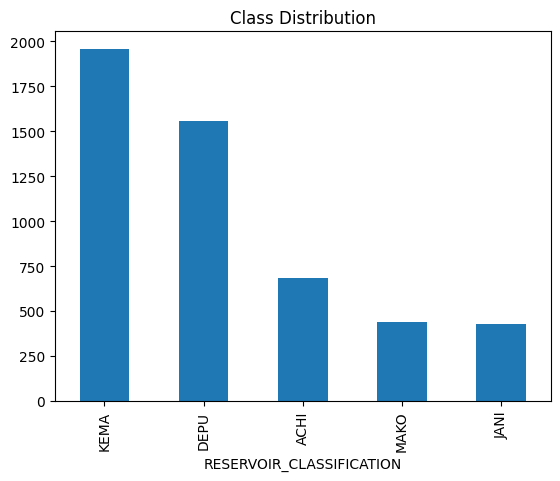

In [33]:
# Distribution of classes
train['RESERVOIR_CLASSIFICATION'].value_counts().plot(kind='bar', title='Class Distribution')


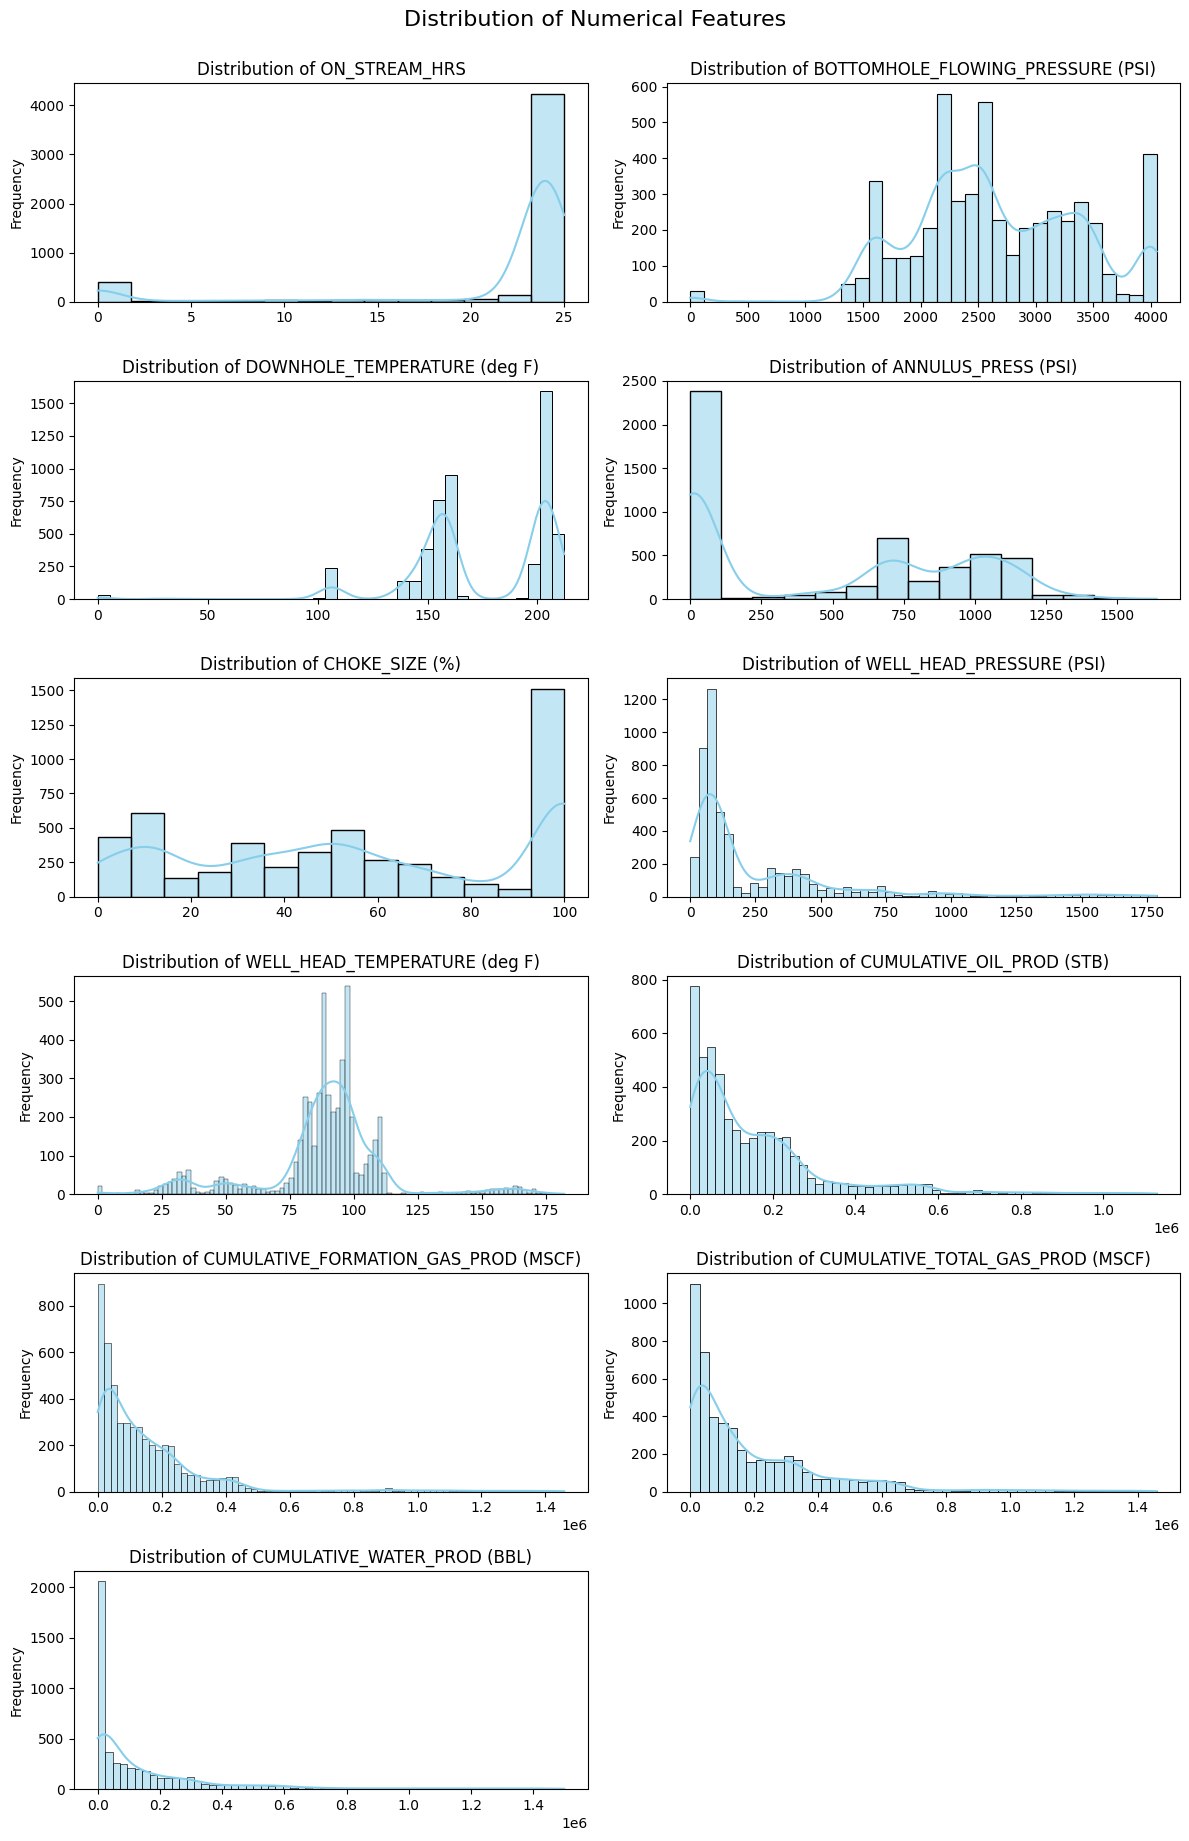

In [34]:
# Select numerical columns, excluding the label
numerical_cols = train.select_dtypes(include=['float64', 'int64']).columns.drop(['RESERVOIR_LABEL'])

# Determine number of subplots (2 columns layout)
num_cols = len(numerical_cols)
n_cols = 2
n_rows = math.ceil(num_cols / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 3))
axes = axes.flatten()

# Plot each feature
for i, col in enumerate(numerical_cols):
    sns.histplot(train[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.02)
plt.show()

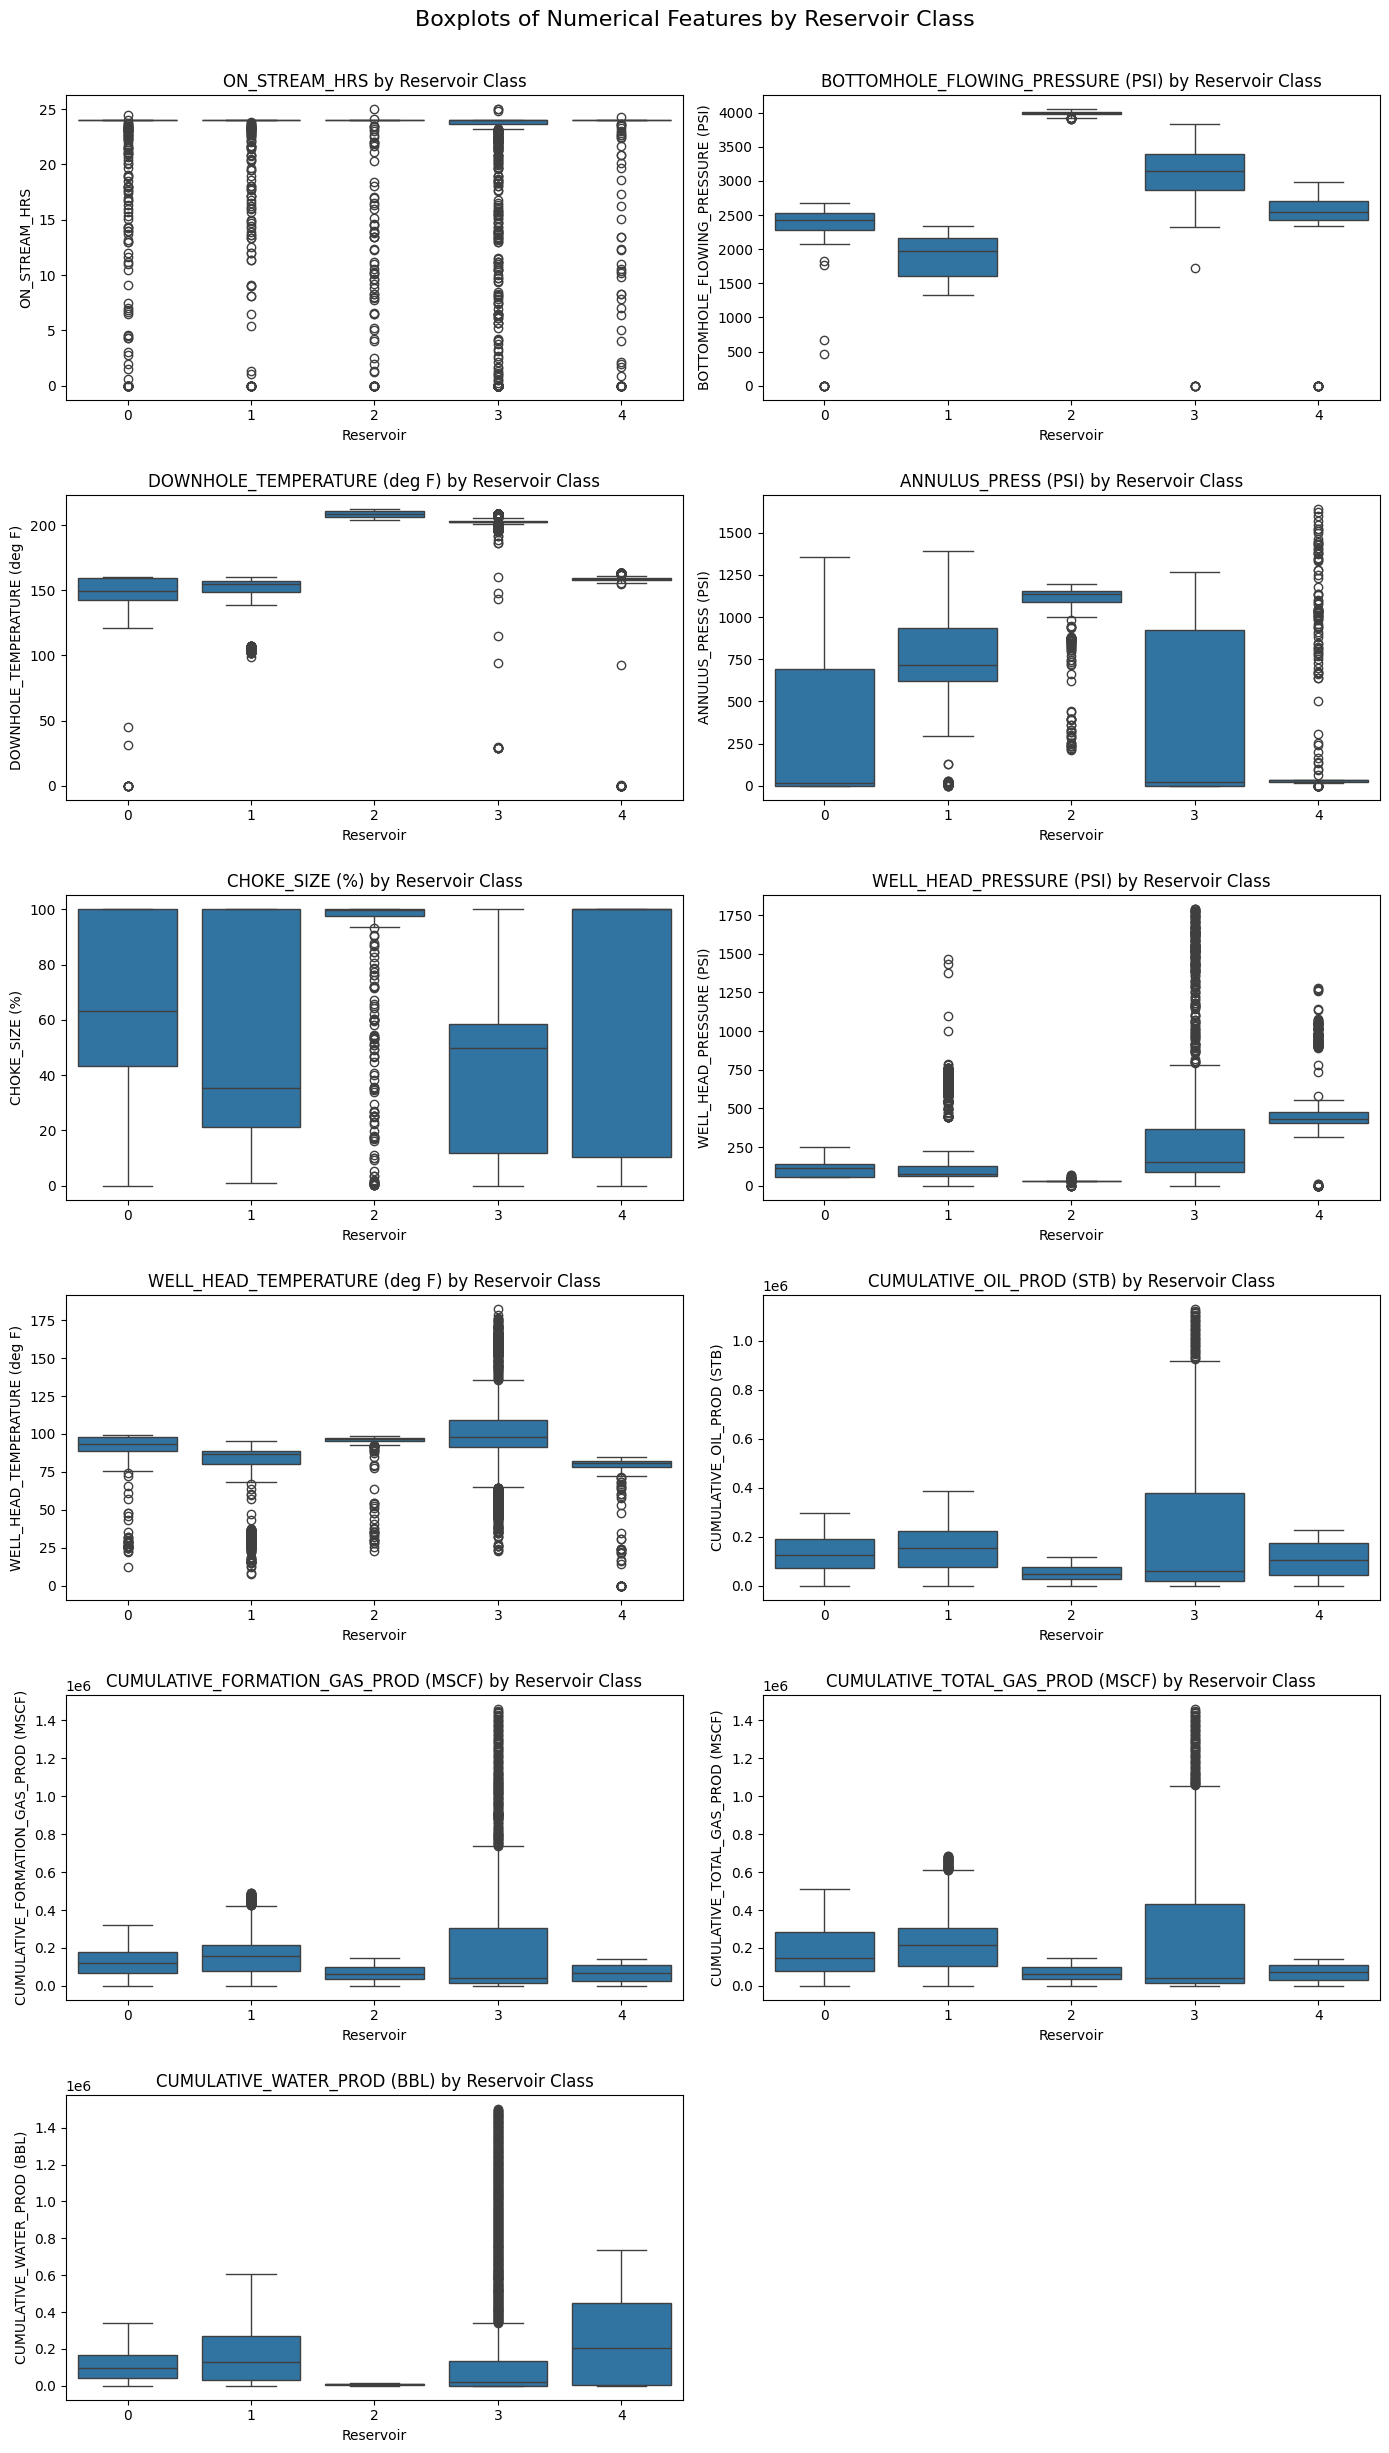

In [35]:
# Select numerical columns (excluding the label)
numerical_cols = train.select_dtypes(include=['float64', 'int64']).columns.drop(['RESERVOIR_LABEL'])

# Determine grid layout
num_cols = len(numerical_cols)
n_cols = 2
n_rows = math.ceil(num_cols / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

# Plot each boxplot
for i, col in enumerate(numerical_cols):
    sns.boxplot(data=train, x='RESERVOIR_LABEL', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Reservoir Class')
    axes[i].set_xlabel('Reservoir')
    axes[i].set_ylabel(col)

# Remove any extra axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Final layout
plt.tight_layout()
plt.suptitle('Boxplots of Numerical Features by Reservoir Class', fontsize=16, y=1.02)
plt.show()

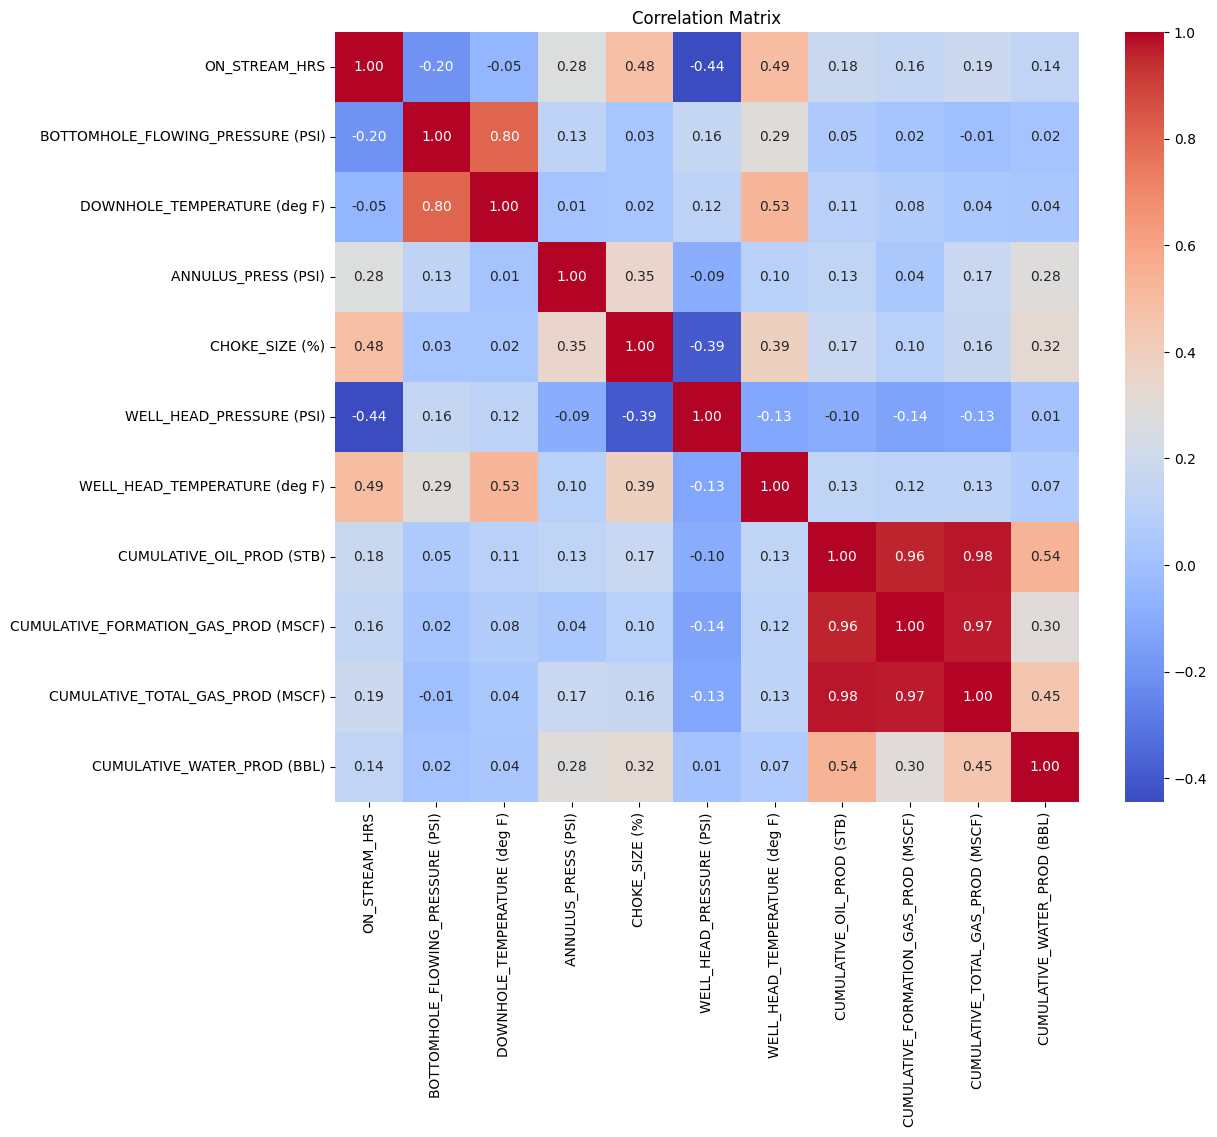

In [36]:
plt.figure(figsize=(12, 10))
sns.heatmap(train[numerical_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [37]:
train.head(3)

,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL),RESERVOIR_CLASSIFICATION,RESERVOIR_LABEL
0,2012-01-01,Well_#2,9.5,3719,203.818,0.0,42.68000,1547.85,70.407,94,66,66,65,KEMA,3
1,2012-01-02,Well_#2,24.0,3640,207.344,0.0,44.57355,1451.32,114.117,885,533,533,365,KEMA,3
2,2012-01-03,Well_#2,24.0,3489,208.116,0.0,46.36498,1388.67,141.521,1802,1118,1118,710,KEMA,3


In [38]:
# Select only numeric columns
numeric_cols = train.select_dtypes(include='number')

# Compute correlation with the target
correlation_with_target = numeric_cols.corr()['RESERVOIR_LABEL'].sort_values(ascending=False)

print(correlation_with_target)

RESERVOIR_LABEL                         1.000000
DOWNHOLE_TEMPERATURE (deg F)            0.536993
BOTTOMHOLE_FLOWING_PRESSURE (PSI)       0.485617
WELL_HEAD_PRESSURE (PSI)                0.351751
WELL_HEAD_TEMPERATURE (deg F)           0.143326
CUMULATIVE_WATER_PROD (BBL)             0.107003
CUMULATIVE_OIL_PROD (STB)               0.073873
CUMULATIVE_FORMATION_GAS_PROD (MSCF)    0.020669
CUMULATIVE_TOTAL_GAS_PROD (MSCF)       -0.042112
CHOKE_SIZE (%)                         -0.142997
ON_STREAM_HRS                          -0.153241
ANNULUS_PRESS (PSI)                    -0.269064
Name: RESERVOIR_LABEL, dtype: float64
